# Fourier Transform and PSD of Sine/Cosine, and Why $\phi(t)\cos(\omega t)$ Keeps the Noise Shape

Illustration for *Modeling Phase Noise in Time Domain*.

1. The Fourier transforms of $\sin$ and $\cos$ differ (imaginary vs. real deltas), but their PSDs are identical:
   $\tfrac14\delta(f\mp f_0)$ — the phase information is gone, only power remains.
2. Multiplying $\phi(t)$ by $\cos(\omega_0 t)$ convolves the PSDs:
   $S_{\phi\cos}(f) = \tfrac14\left[S_\phi(f-f_0) + S_\phi(f+f_0)\right]$. The noise shape is preserved, just shifted
   to $\pm f_0$, and the total power is $\tfrac12\langle\phi^2\rangle$ — so relative to the carrier power $\tfrac12$,
   the ratio is exactly $\langle\phi^2\rangle$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#52514e", "axes.labelcolor": "#0b0b0b",
    "xtick.color": "#52514e", "ytick.color": "#52514e",
    "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.8,
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
})
BLUE, ORANGE, AQUA, INK, MUTED = "#2a78d6", "#eb6834", "#1baf7a", "#0b0b0b", "#52514e"

rng = np.random.default_rng(42)
fs = 1.0e3          # sample rate (normalized units)
N  = 1 << 20
t  = np.arange(N) / fs
f0 = 100.0          # carrier frequency

## 1. Fourier transform vs. PSD of $\sin$ and $\cos$

$$\mathcal{F}\{\cos\omega_0 t\} = \tfrac12\left[\delta(f-f_0)+\delta(f+f_0)\right],\qquad
\mathcal{F}\{\sin\omega_0 t\} = \tfrac{1}{2j}\left[\delta(f-f_0)-\delta(f+f_0)\right]$$

The PSD is $|X(f)|^2$ (per unit time), so both become $\tfrac14\left[\delta(f-f_0)+\delta(f+f_0)\right]$, integrating to $\tfrac12$.

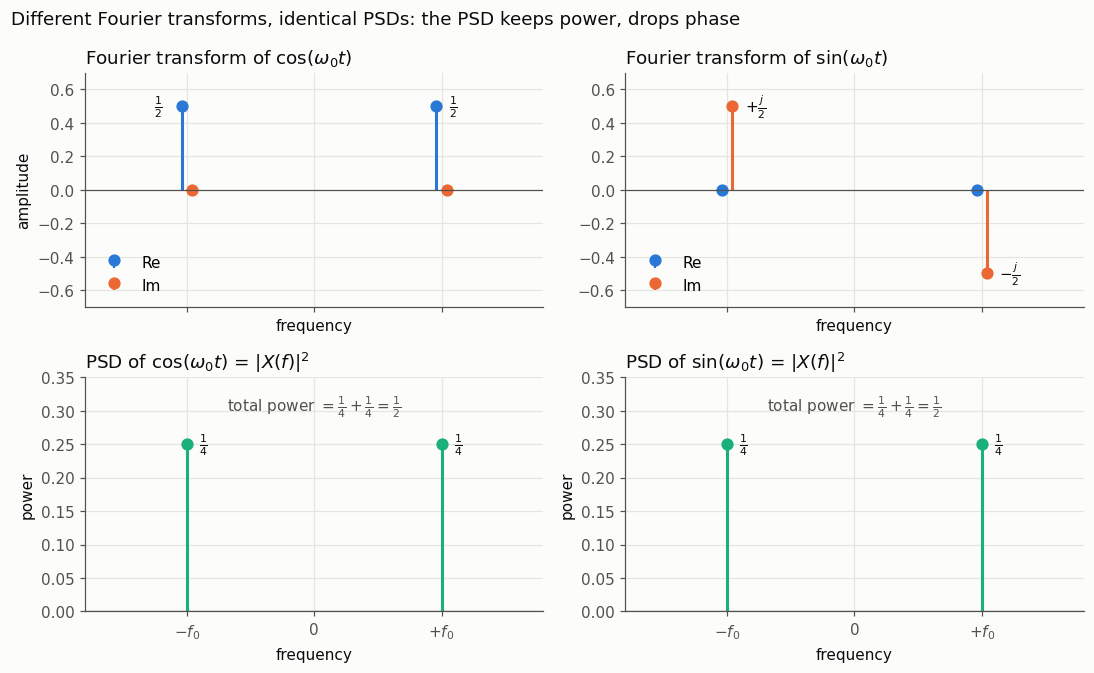

In [2]:
def stem(ax, x, y, color, label=None, offset=0.0):
    ml, sl, bl = ax.stem(np.asarray(x) + offset, y, basefmt=" ", label=label)
    plt.setp(sl, color=color, linewidth=2); plt.setp(ml, color=color, markersize=7)

def style(ax, title, ylim):
    ax.set_title(title, loc="left", color=INK)
    ax.axhline(0, color=MUTED, linewidth=0.8)
    ax.set_xlim(-1.8*f0, 1.8*f0); ax.set_ylim(*ylim)
    ax.set_xticks([-f0, 0, f0]); ax.set_xticklabels([r"$-f_0$", "0", r"$+f_0$"])
    ax.set_xlabel("frequency")

fig, axs = plt.subplots(2, 2, figsize=(10, 6.2), sharex=True)
d = 0.04 * f0   # small horizontal offset so Re/Im stems don't overlap

# FT of cos: purely real
ax = axs[0, 0]
stem(ax, [-f0, f0], [0.5, 0.5], BLUE, "Re", -d)
stem(ax, [-f0, f0], [0, 0], ORANGE, "Im", d)
style(ax, r"Fourier transform of $\cos(\omega_0 t)$", (-0.7, 0.7))
ax.annotate(r"$\frac{1}{2}$", (f0 - d, 0.5), xytext=(8, 0), textcoords="offset points", va="center", color=INK)
ax.annotate(r"$\frac{1}{2}$", (-f0 - d, 0.5), xytext=(-18, 0), textcoords="offset points", va="center", color=INK)
ax.legend(frameon=False, loc="lower left")

# FT of sin: purely imaginary, odd
ax = axs[0, 1]
stem(ax, [-f0, f0], [0, 0], BLUE, "Re", -d)
stem(ax, [-f0, f0], [0.5, -0.5], ORANGE, "Im", d)
style(ax, r"Fourier transform of $\sin(\omega_0 t)$", (-0.7, 0.7))
ax.annotate(r"$+\frac{j}{2}$", (-f0 + d, 0.5), xytext=(8, 0), textcoords="offset points", va="center", color=INK)
ax.annotate(r"$-\frac{j}{2}$", (f0 + d, -0.5), xytext=(8, 0), textcoords="offset points", va="center", color=INK)
ax.legend(frameon=False, loc="lower left")

# PSDs: identical
for ax, name in zip(axs[1], [r"\cos", r"\sin"]):
    stem(ax, [-f0, f0], [0.25, 0.25], AQUA)
    style(ax, rf"PSD of ${name}(\omega_0 t)$ = $|X(f)|^2$", (0, 0.35))
    for x in (-f0, f0):
        ax.annotate(r"$\frac{1}{4}$", (x, 0.25), xytext=(8, 0), textcoords="offset points", va="center", color=INK)
    ax.text(0, 0.30, r"total power $= \frac{1}{4}+\frac{1}{4} = \frac{1}{2}$", ha="center", color=MUTED)
    ax.set_ylabel("power")
axs[0, 0].set_ylabel("amplitude")

fig.suptitle("Different Fourier transforms, identical PSDs: the PSD keeps power, drops phase",
             x=0.01, ha="left", fontsize=12, color=INK)
fig.tight_layout()
fig.savefig("sin-cos-ft-psd.png", bbox_inches="tight")
plt.show()

## 2. Mixing $\phi(t)$ with $\cos(\omega_0 t)$ = convolving the PSDs

Take $\phi(t)$ as small, zero-mean, low-pass Gaussian noise (a stand-in for phase noise) with rms
$\sigma_\phi = 0.01$ rad. Then compare the two-sided PSD of $\phi(t)$, the carrier PSD, and the PSD of the product
against the prediction $\tfrac14[S_\phi(f-f_0)+S_\phi(f+f_0)]$.

In [3]:
sigma_phi = 0.01
b, a = signal.butter(2, 20.0, fs=fs)                 # 20 Hz low-pass shaping
phi = signal.lfilter(b, a, rng.standard_normal(N))
phi *= sigma_phi / phi.std()

carrier = np.cos(2*np.pi*f0*t)
mixed   = phi * carrier

def psd2(x):
    f, P = signal.welch(x, fs=fs, nperseg=1 << 12, detrend=False, return_onesided=False)
    idx = np.argsort(f)
    return f[idx], P[idx]

f, S_phi = psd2(phi)
_, S_mix = psd2(mixed)
S_pred = 0.25 * (np.interp(f - f0, f, S_phi, left=0, right=0) +
                 np.interp(f + f0, f, S_phi, left=0, right=0))

P_phi, P_mix, P_car = np.trapezoid(S_phi, f), np.trapezoid(S_mix, f), np.mean(carrier**2)
print(f"<phi^2>                     = {P_phi:.3e}  (direct var: {phi.var():.3e})")
print(f"power of phi*cos            = {P_mix:.3e}  (direct: {np.mean(mixed**2):.3e})")
print(f"ratio (phi*cos) / <phi^2>   = {P_mix / P_phi:.4f}   (expect 0.5)")
print(f"carrier power               = {P_car:.4f}      (expect 0.5)")
print(f"PN = P_mix / P_carrier      = {P_mix / P_car:.3e}  vs <phi^2> = {P_phi:.3e}")

<phi^2>                     = 9.988e-05  (direct var: 1.000e-04)
power of phi*cos            = 4.994e-05  (direct: 5.000e-05)
ratio (phi*cos) / <phi^2>   = 0.5000   (expect 0.5)
carrier power               = 0.5000      (expect 0.5)
PN = P_mix / P_carrier      = 9.988e-05  vs <phi^2> = 9.988e-05


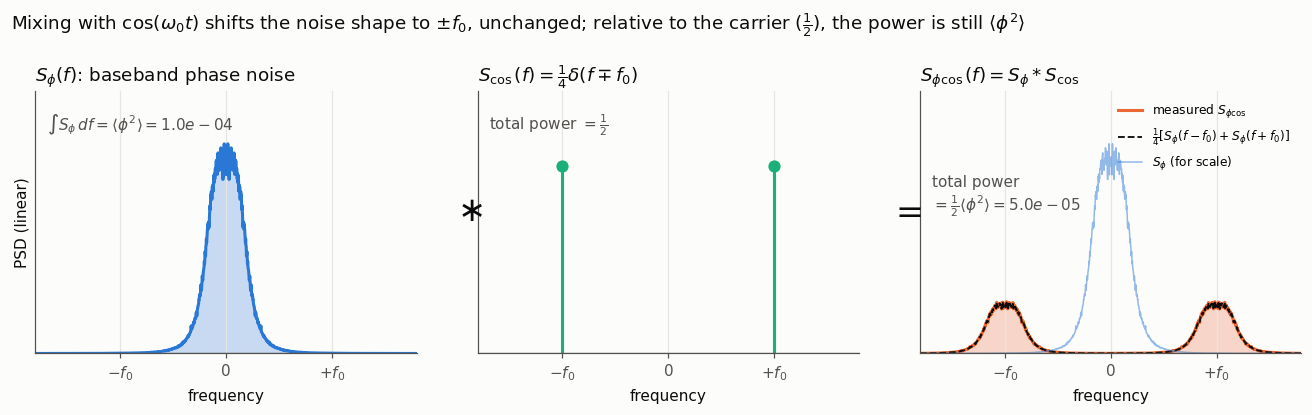

In [4]:
fig, axs = plt.subplots(1, 3, figsize=(12, 3.8), sharex=True)
ymax = S_phi.max() * 1.25

ax = axs[0]
ax.fill_between(f, S_phi, color=BLUE, alpha=0.25, linewidth=0)
ax.plot(f, S_phi, color=BLUE, linewidth=2)
ax.set_title(r"$S_\phi(f)$: baseband phase noise", loc="left", color=INK)
ax.text(0.03, 0.92, rf"$\int S_\phi\,df = \langle\phi^2\rangle = {P_phi:.1e}$",
        transform=ax.transAxes, color=MUTED, va="top")
ax.set_ylim(0, ymax)

ax = axs[1]
ml, sl, _ = ax.stem([-f0, f0], [0.25, 0.25], basefmt=" ")
plt.setp(sl, color=AQUA, linewidth=2); plt.setp(ml, color=AQUA, markersize=7)
ax.set_title(r"$S_{\cos}(f) = \frac{1}{4}\delta(f\mp f_0)$", loc="left", color=INK)
ax.set_ylim(0, 0.35)
ax.text(0.03, 0.92, r"total power $= \frac{1}{2}$", transform=ax.transAxes, color=MUTED, va="top")

ax = axs[2]
ax.fill_between(f, S_mix, color=ORANGE, alpha=0.25, linewidth=0)
ax.plot(f, S_mix, color=ORANGE, linewidth=2, label=r"measured $S_{\phi\cos}$")
ax.plot(f, S_pred, color=INK, linewidth=1.2, linestyle="--",
        label=r"$\frac{1}{4}[S_\phi(f-f_0)+S_\phi(f+f_0)]$")
ax.plot(f, S_phi, color=BLUE, linewidth=1, alpha=0.5, label=r"$S_\phi$ (for scale)")
ax.set_title(r"$S_{\phi\cos}(f) = S_\phi * S_{\cos}$", loc="left", color=INK)
ax.text(0.03, 0.68, "total power\n" + rf"$= \frac{{1}}{{2}}\langle\phi^2\rangle = {P_mix:.1e}$",
        transform=ax.transAxes, color=MUTED, va="top")
ax.set_ylim(0, ymax)
ax.legend(frameon=False, loc="upper right", fontsize=8)

for ax in axs:
    ax.axhline(0, color=MUTED, linewidth=0.8)
    ax.set_xlim(-1.8*f0, 1.8*f0)
    ax.set_xticks([-f0, 0, f0]); ax.set_xticklabels([r"$-f_0$", "0", r"$+f_0$"])
    ax.set_xlabel("frequency")
    ax.set_yticks([])
axs[0].set_ylabel("PSD (linear)")

for x0, x1, s in [(0.345, 0.37, r"$\ast$"), (0.675, 0.70, r"$=$")]:
    fig.text((x0 + x1) / 2, 0.5, s, fontsize=22, ha="center", va="center", color=INK)

fig.suptitle(r"Mixing with $\cos(\omega_0 t)$ shifts the noise shape to $\pm f_0$, unchanged; "
             r"relative to the carrier ($\frac{1}{2}$), the power is still $\langle\phi^2\rangle$",
             x=0.01, ha="left", fontsize=12, color=INK)
fig.tight_layout(w_pad=4)
fig.savefig("phase-deviation-convolution.png", bbox_inches="tight")
plt.show()

## 3. From the voltage PSD to the phase noise PSD

Now look at the actual waveform $V(t) = \sin(\omega_0 t + \phi(t))$, as a spectrum analyzer would. Its one-sided
voltage PSD is a carrier line of power $P_c = \tfrac12$ at $f_0$, plus noise skirts
$S_V(f_0 + \Delta f) \approx \tfrac12 S_\phi(\Delta f)$ (two-sided $S_\phi$). Dividing the skirt by the carrier power gives

$$\mathcal{L}(\Delta f) = \frac{S_V(f_0+\Delta f)}{P_c} = S_\phi(\Delta f) \quad [\text{dBc/Hz}]$$

— the phase noise PSD can be read straight off the voltage PSD, and it matches the PSD of $\phi(t)$ itself.

In [5]:
V = np.sin(2*np.pi*f0*t + phi)

# one-sided voltage PSD, fine resolution + low-leakage window so the skirt is visible next to the carrier
fv, S_V = signal.welch(V, fs=fs, window="blackmanharris", nperseg=1 << 16, detrend=False)
df = fv[1] - fv[0]

# carrier power = integrate the carrier line over its window main lobe
k0 = np.argmin(abs(fv - f0))
lobe = slice(k0 - 6, k0 + 7)
P_c = S_V[lobe].sum() * df
print(f"carrier power from PSD = {P_c:.4f}  (expect 0.5)")

# L(Δf): upper skirt normalized by carrier power, vs two-sided S_phi measured directly from phi
dfo = fv[k0 + 8:] - f0                     # offsets beyond the carrier main lobe
L = S_V[k0 + 8:] / P_c
fp, S_phi1 = signal.welch(phi, fs=fs, nperseg=1 << 14, detrend=False)   # one-sided
S_phi2 = S_phi1 / 2                                                        # -> two-sided
m = (dfo > 0.3) & (dfo < 300)
print(f"L(10 Hz)  from V: {10*np.log10(np.interp(10, dfo, L)):.1f} dBc/Hz,"
      f"  S_phi(10 Hz): {10*np.log10(np.interp(10, fp, S_phi2)):.1f} dB rad²/Hz")

carrier power from PSD = 0.4999  (expect 0.5)
L(10 Hz)  from V: -55.6 dBc/Hz,  S_phi(10 Hz): -56.3 dB rad²/Hz


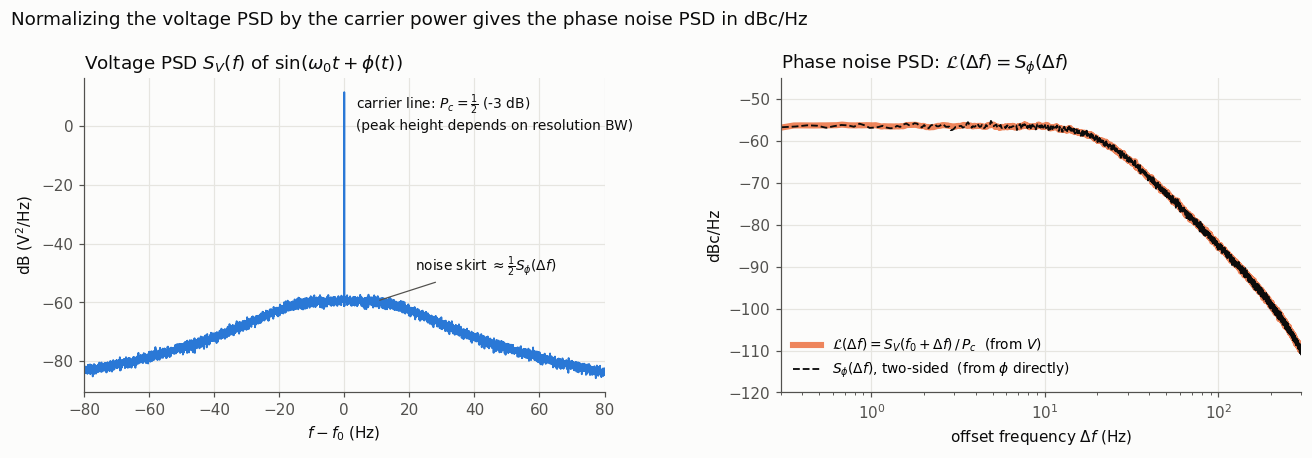

In [6]:
def smooth(x, n=31):
    return np.convolve(x, np.ones(n)/n, mode="same")   # light smoothing, display only

fig, axs = plt.subplots(1, 2, figsize=(12, 4.2))

ax = axs[0]
sel = (fv > f0 - 80) & (fv < f0 + 80)
ax.plot(fv[sel] - f0, 10*np.log10(S_V[sel]), color=BLUE, linewidth=1.2)
ax.set_title(r"Voltage PSD $S_V(f)$ of $\sin(\omega_0 t + \phi(t))$", loc="left", color=INK)
ax.set_xlabel(r"$f - f_0$ (Hz)")
ax.set_ylabel(r"dB (V$^2$/Hz)")
ax.set_xlim(-80, 80)
ax.annotate(rf"carrier line: $P_c = \frac{{1}}{{2}}$ ({10*np.log10(P_c):.0f} dB)" "\n"
            "(peak height depends on resolution BW)",
            xy=(0, 10*np.log10(S_V[k0])), xytext=(8, 0), textcoords="offset points",
            va="top", color=INK, fontsize=9)
x_mark = 10
y_skirt = 10*np.log10(np.interp(f0 + x_mark, fv, smooth(S_V)))
ax.annotate(r"noise skirt $\approx \frac{1}{2}S_\phi(\Delta f)$", xy=(x_mark, y_skirt),
            xytext=(25, 20), textcoords="offset points", color=INK, fontsize=9,
            arrowprops=dict(arrowstyle="-", color=MUTED, linewidth=0.8))

ax = axs[1]
ax.semilogx(dfo[m], 10*np.log10(smooth(L)[m]), color=ORANGE, linewidth=4, alpha=0.8,
            label=r"$\mathcal{L}(\Delta f) = S_V(f_0+\Delta f)\,/\,P_c$  (from $V$)")
ax.semilogx(fp[fp > 0.3], 10*np.log10(S_phi2[fp > 0.3]), color=INK, linewidth=1.2, linestyle="--",
            label=r"$S_\phi(\Delta f)$, two-sided  (from $\phi$ directly)")
ax.set_xlim(0.3, 300)
ax.set_ylim(-120, -45)
ax.set_title(r"Phase noise PSD: $\mathcal{L}(\Delta f) = S_\phi(\Delta f)$", loc="left", color=INK)
ax.set_xlabel(r"offset frequency $\Delta f$ (Hz)")
ax.set_ylabel("dBc/Hz")
ax.legend(frameon=False, loc="lower left", fontsize=9)

fig.suptitle("Normalizing the voltage PSD by the carrier power gives the phase noise PSD in dBc/Hz",
             x=0.01, ha="left", fontsize=12, color=INK)
fig.tight_layout(w_pad=3)
fig.savefig("voltage-psd-to-phase-noise.png", bbox_inches="tight")
plt.show()

## 4. The shape of a typical oscillator phase noise: $-30$, $-20$, then flat

The oscillator core sees input-referred voltage noise with a flicker ($1/f$, $-10$ dB/dec) and a white part. Voltage-to-phase
integration ($1/s$, i.e. $1/f^2$ in power) turns these into $-30$ and $-20$ dB/dec. A non-integrating stage (e.g. a clock
buffer) converts its white noise directly into phase, adding a flat floor:

$$\mathcal{L}(\Delta f) = \frac{a}{\Delta f^3} + \frac{b}{\Delta f^2} + c$$

We synthesize $\phi(t)$ with exactly this two-sided PSD, build $V(t) = \sin(\omega_0 t + \phi(t))$, and read $\mathcal{L}(\Delta f)$
back off the voltage PSD. Below 100 Hz the PSD is held flat so that $\sigma_\phi$ stays small (small-angle approximation) —
in reality the $1/f^3$ region keeps growing, which is exactly the low-offset caveat in the post.

In [7]:
fs2, N2, f02 = 2.0e6, 1 << 23, 500e3          # 2 MS/s, ~4.2 s record, 500 kHz carrier
t2 = np.arange(N2) / fs2

f_fl = 5e3                                      # flicker corner (−30 → −20)
b_  = 10**(-100/10) * (10e3)**2                 # −100 dBc/Hz at 10 kHz on the 1/f² part
a_  = b_ * f_fl                                 # 1/f³ meets 1/f² at 5 kHz
c_  = 10**(-120/10)                             # −120 dBc/Hz floor (buffer)
f_floor = np.sqrt(b_ / c_)                      # 1/f² meets the floor
L_model = lambda x: a_/x**3 + b_/x**2 + c_

# synthesize phi with two-sided PSD L_model (flattened below 100 Hz to keep sigma_phi small)
fk = np.fft.rfftfreq(N2, 1/fs2)
S2 = L_model(np.maximum(fk, 100.0)); S2[0] = 0
S2[fk > 450e3] = 0                              # band-limit so sidebands don't alias past fs/2
X = np.sqrt(S2 * fs2 * N2) * np.exp(1j * rng.uniform(0, 2*np.pi, fk.size))   # E|X_k|^2 = N fs S(f_k)
phi2 = np.fft.irfft(X, n=N2)
print(f"sigma_phi = {phi2.std():.3f} rad   (small-angle OK)")
print(f"corners: flicker {f_fl/1e3:.0f} kHz, floor {f_floor/1e3:.0f} kHz")

V2 = np.sin(2*np.pi*f02*t2 + phi2)
win = ("kaiser", 30)                            # very low sidelobes, so carrier leakage stays below the -120 dBc floor
fv2, SV2 = signal.welch(V2, fs=fs2, window=win, nperseg=1 << 18, detrend=False)
k2 = np.argmin(abs(fv2 - f02)); guard = 16
P_c2 = SV2[k2-guard:k2+guard+1].sum() * (fv2[1] - fv2[0])
off = fv2[k2+guard:] - f02
L_meas = SV2[k2+guard:] / P_c2
print(f"carrier power from PSD = {P_c2:.4f}")
for x in (1e3, 10e3, 300e3):
    print(f"L({x/1e3:>5.0f} kHz): measured {10*np.log10(np.interp(x, off, L_meas)):7.1f}   model {10*np.log10(L_model(x)):7.1f} dBc/Hz")

sigma_phi = 0.124 rad   (small-angle OK)
corners: flicker 5 kHz, floor 100 kHz


carrier power from PSD = 0.4984
L(    1 kHz): measured   -72.2   model   -72.2 dBc/Hz
L(   10 kHz): measured   -97.8   model   -98.2 dBc/Hz
L(  300 kHz): measured  -119.4   model  -119.5 dBc/Hz


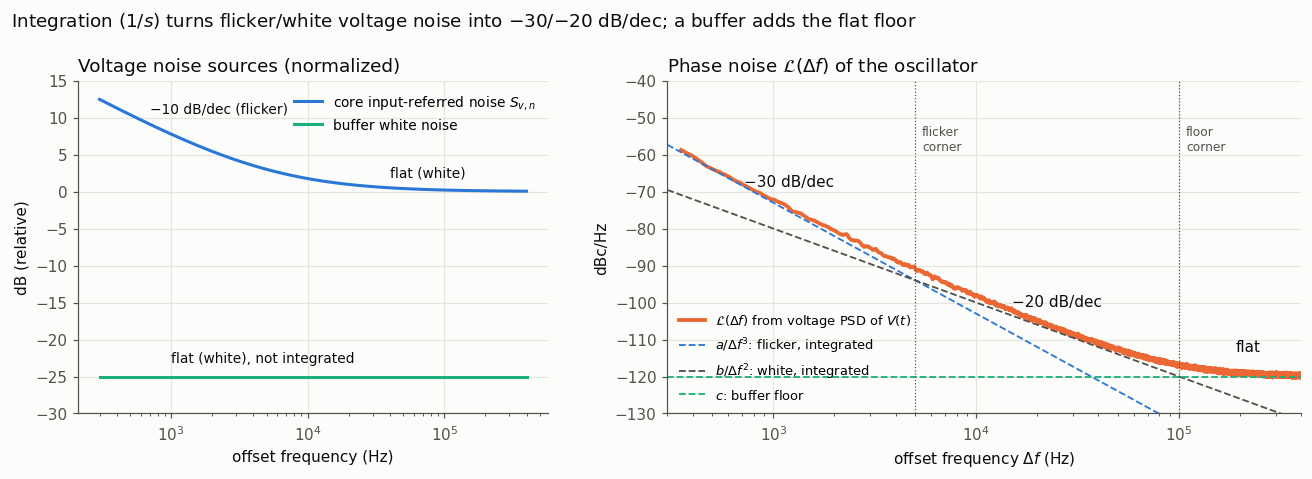

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4.4), gridspec_kw={"width_ratios": [1, 1.35]})
x = np.logspace(np.log10(300), np.log10(400e3), 400)

# left: noise sources (normalized, dB) and what integration does to them
ax = axs[0]
Svn = f_fl / x + 1                               # input-referred: 1/f + white, corner at f_fl
ax.semilogx(x, 10*np.log10(Svn), color=BLUE, linewidth=2, label=r"core input-referred noise $S_{v,n}$")
ax.semilogx(x, 10*np.log10(np.full_like(x, 1.0)) - 25, color=AQUA, linewidth=2, label="buffer white noise")
ax.text(700, 10*np.log10(f_fl/700 + 1) + 1.5, "−10 dB/dec (flicker)", color=INK, fontsize=9)
ax.text(40e3, 2.0, "flat (white)", color=INK, fontsize=9)
ax.text(1e3, -23, "flat (white), not integrated", color=INK, fontsize=9)
ax.set_ylim(-30, 15)
ax.set_title("Voltage noise sources (normalized)", loc="left", color=INK)
ax.set_xlabel("offset frequency (Hz)"); ax.set_ylabel("dB (relative)")
ax.legend(frameon=False, loc="upper right", fontsize=9)

# right: measured L(Δf) from V(t), with the three asymptotes
ax = axs[1]
mm = (off > 350) & (off < 400e3)
Ls = np.exp(np.convolve(np.log(L_meas), np.ones(15)/15, mode="same"))          # light smoothing for display
ax.semilogx(off[mm], 10*np.log10(Ls[mm]), color=ORANGE, linewidth=2.5,
            label=r"$\mathcal{L}(\Delta f)$ from voltage PSD of $V(t)$")
ax.semilogx(x, 10*np.log10(a_/x**3), color=BLUE, linewidth=1.2, linestyle="--", label=r"$a/\Delta f^3$: flicker, integrated")
ax.semilogx(x, 10*np.log10(b_/x**2), color=MUTED, linewidth=1.2, linestyle="--", label=r"$b/\Delta f^2$: white, integrated")
ax.semilogx(x, 10*np.log10(np.full_like(x, c_)), color=AQUA, linewidth=1.2, linestyle="--", label=r"$c$: buffer floor")
for fc, name in [(f_fl, "flicker\ncorner"), (f_floor, "floor\ncorner")]:
    ax.axvline(fc, color=MUTED, linewidth=0.8, linestyle=":")
    ax.text(fc*1.08, -52, name, color=MUTED, fontsize=8, va="top")
for xx, s in [(1.2e3, "−30 dB/dec"), (25e3, "−20 dB/dec"), (2.2e5, "flat")]:
    ax.text(xx, 10*np.log10(L_model(xx)) + 6, s, color=INK, fontsize=10, ha="center")
ax.set_xlim(300, 400e3); ax.set_ylim(-130, -40)
ax.set_title(r"Phase noise $\mathcal{L}(\Delta f)$ of the oscillator", loc="left", color=INK)
ax.set_xlabel(r"offset frequency $\Delta f$ (Hz)"); ax.set_ylabel("dBc/Hz")
ax.legend(frameon=False, loc="lower left", fontsize=8.5)

fig.suptitle(r"Integration ($1/s$) turns flicker/white voltage noise into $-30$/$-20$ dB/dec; a buffer adds the flat floor",
             x=0.01, ha="left", fontsize=12, color=INK)
fig.tight_layout(w_pad=3)
fig.savefig("oscillator-phase-noise-shape.png", bbox_inches="tight")
plt.show()